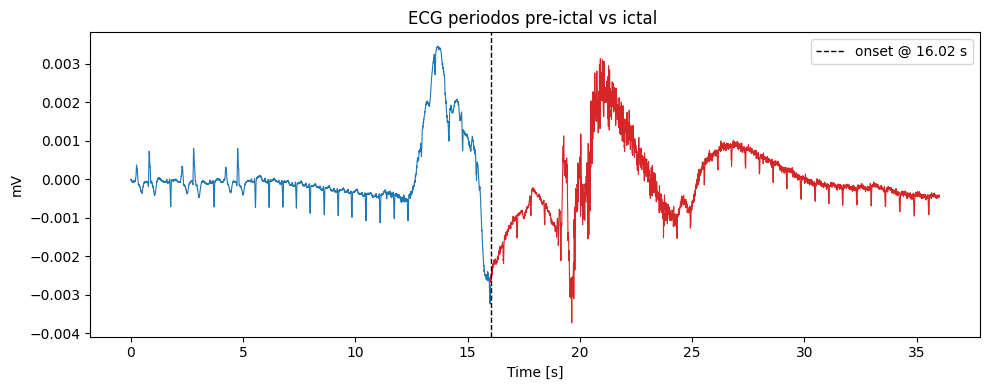

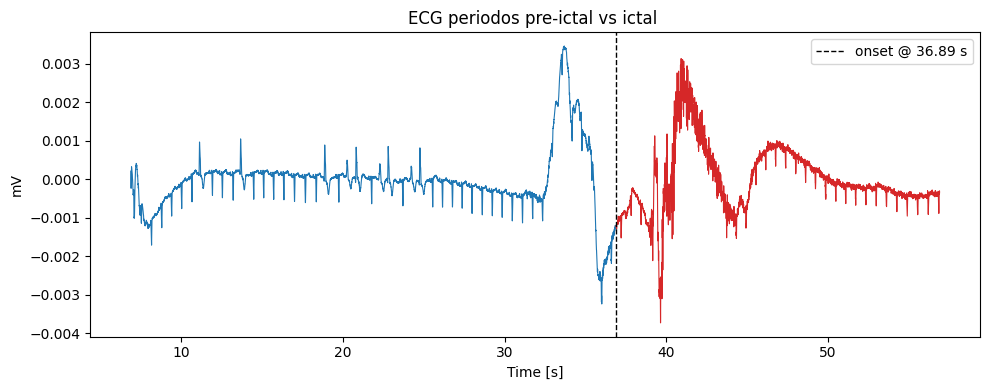

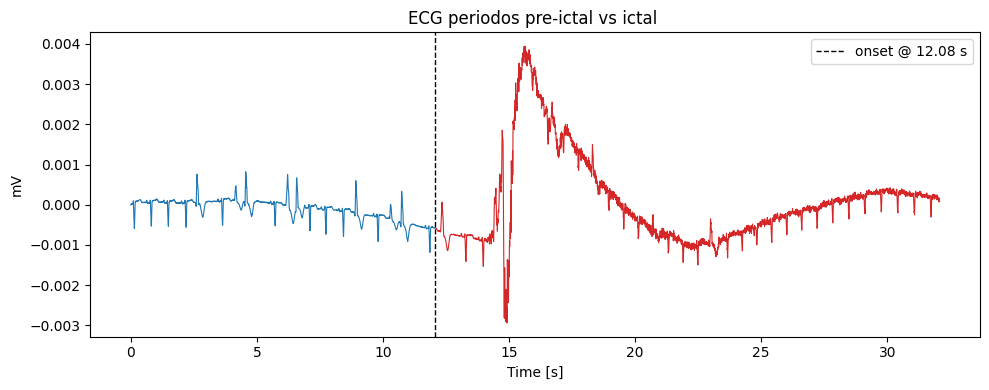

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt


def denoise_ecg(signal: np.ndarray,
                fs: float = 256,
                lp_cut: float = 45.0,
                mains_freq: float = 50.0,
                q: float = 30.0) -> np.ndarray:
    """
    Remove only high-frequency noise and power-line hum from a raw ECG,
    but leave baseline wander (0–0.5 Hz) untouched.

    Parameters
    ----------
    signal : 1-D array_like
        Raw ECG samples (in mV).
    fs : float
        Sampling frequency in Hz (default: 256 Hz).
    lp_cut : float
        Low-pass cutoff in Hz (default: 45.0 Hz). Frequencies above this get
        attenuated to remove EMG/motion/quantization noise.
    mains_freq : float
        Power-line frequency in Hz (default: 50.0 Hz).
    q : float
        Quality factor for the notch filter (default: 30).

    Returns
    -------
    clean : 1-D numpy array
        Filtered ECG with baseline wander preserved.
    """

    # 1) Low-pass 4th-order Butterworth at lp_cut Hz to remove > lp_cut Hz noise
    #    (EMG bursts, high-freq quantization artifacts, etc.)
    sos_lp = butter(
        N=4,
        Wn=lp_cut,
        btype='low',
        fs=fs,
        output='sos'
    )
    lowpassed = sosfiltfilt(sos_lp, signal)

    # 2) Notch filter at mains_freq to remove power-line interference
    #    (we still apply it, even though LP at 45 Hz already suppresses 50 Hz,
    #     because the transition band of a 4th-order Butterworth isn’t perfectly
    #     brick-wall—some 50 Hz leakage can remain).
    b_notch, a_notch = iirnotch(w0=mains_freq, Q=q, fs=fs)
    clean = filtfilt(b_notch, a_notch, lowpassed)

    clean = (clean-clean.mean())/clean.std()

    return clean


def plot_onset_window(path: str, denoise: bool,
                      fs: int = 256,
                      pre_sec: int = 30,
                      post_sec: int = 20):

    df = pd.read_csv(path).iloc[1:].reset_index(drop=True)
    t = df["Time [s]"].values
    sig = df["Signal [mV]"].astype(float).values
    lbl = df["Seizure [bool]"].astype(bool).values
    if denoise == True:
        sig = denoise_ecg(sig)

    try:
        onset_idx = np.flatnonzero(lbl)[0]
    except IndexError:
        raise ValueError(f"No seizure found in {path}")

    n_pre = int(pre_sec * fs)
    n_post = int(post_sec * fs)

    i0 = max(0,           onset_idx - n_pre)
    i1 = min(len(sig),    onset_idx + n_post)

    plt.figure(figsize=(10, 4))

    plt.plot(t[i0:onset_idx], sig[i0:onset_idx],
             color="tab:blue", lw=0.8)

    plt.plot(t[onset_idx:i1], sig[onset_idx:i1],
             color="tab:red",  lw=0.8)

    plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
                label=f"onset @ {t[onset_idx]:.2f} s")

    plt.xlabel("Time [s]")
    plt.ylabel("mV")
    plt.title("ECG periodos pre-ictal vs ictal ")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_onset_window(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s002_t000.csv", denoise=False)
plot_onset_window(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s001_t000.csv", denoise=False)
plot_onset_window(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s001_t001.csv", denoise=False)

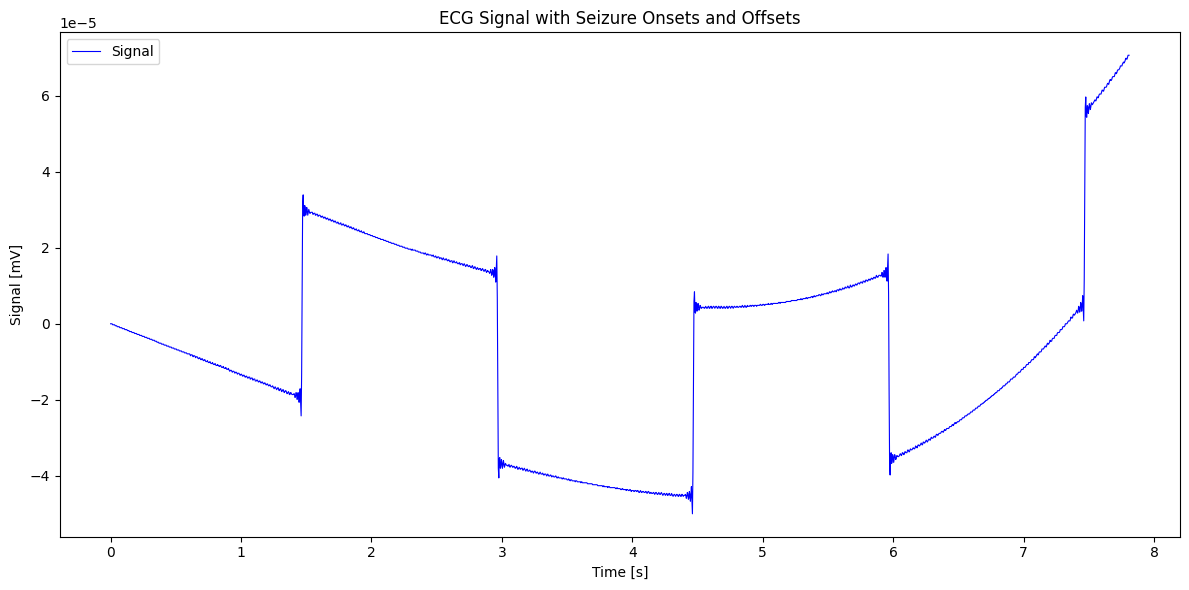

In [ ]:
# Find seizure onsets and offsets
df = pd.read_csv(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaajy_s001_t000.csv")
df = df.iloc[:2000]
onsets, offsets = find_label_edges(df["Seizure [bool]"].values.astype(bool))

# Plot the signal
plt.figure(figsize=(12, 6))
plt.plot(df["Time [s]"], df["Signal [mV]"],
         label="Signal", color="blue", lw=0.8)

# Mark seizure onsets and offsets
for onset in onsets:
    plt.axvline(df["Time [s]"].iloc[onset], color="green",
                linestyle="--", label="Seizure Onset")
for offset in offsets:
    plt.axvline(df["Time [s]"].iloc[offset], color="red",
                linestyle="--", label="Seizure Offset")

plt.xlabel("Time [s]")
plt.ylabel("Signal [mV]")
plt.title("ECG Signal with Seizure Onsets and Offsets")
plt.legend()
plt.tight_layout()
plt.show()

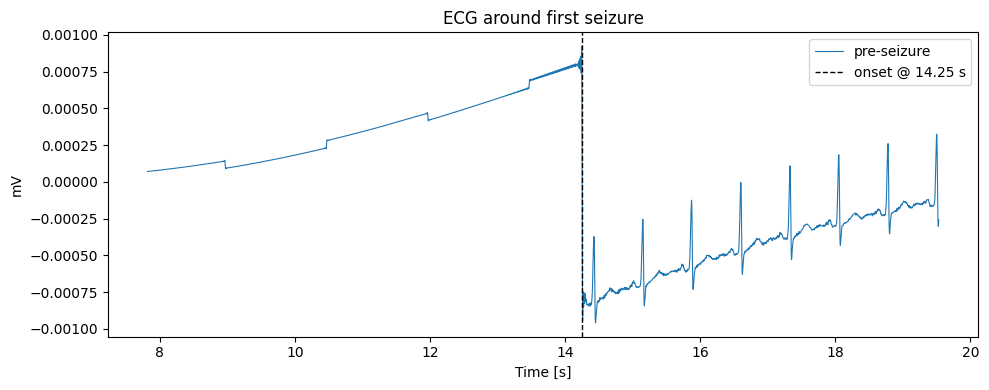

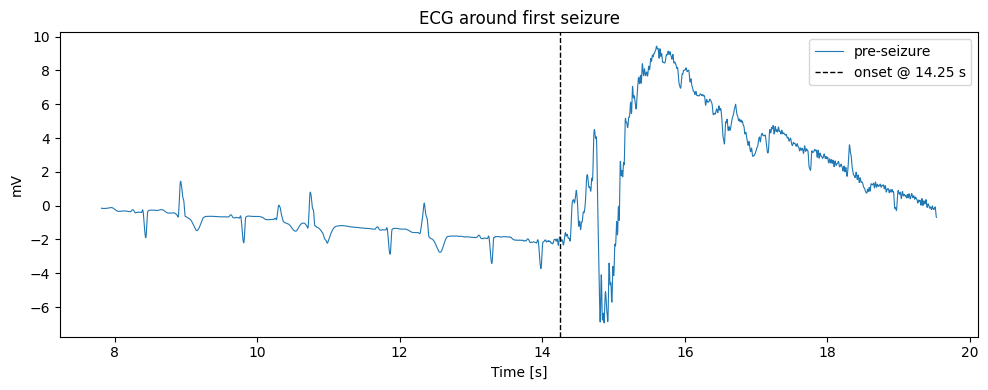

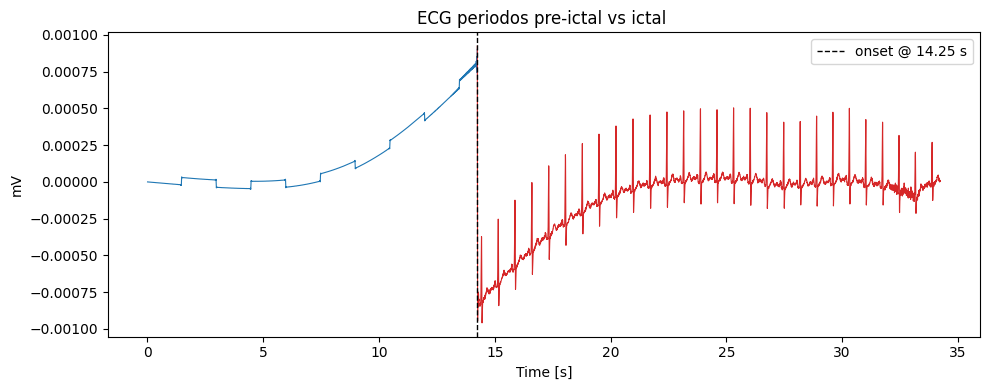

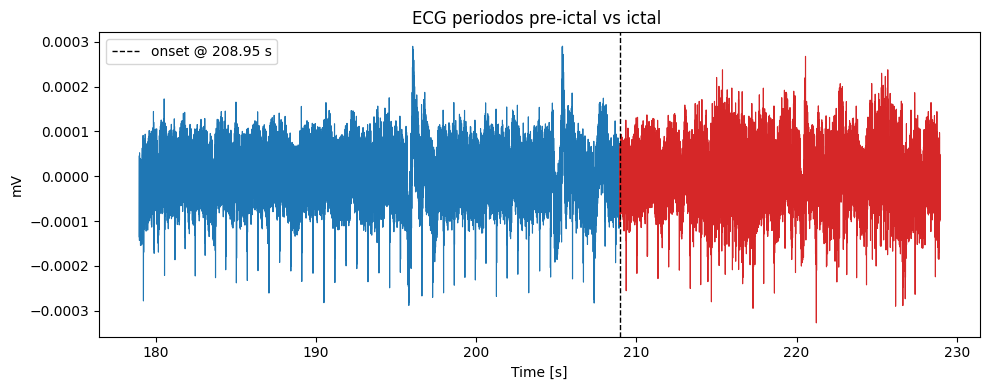

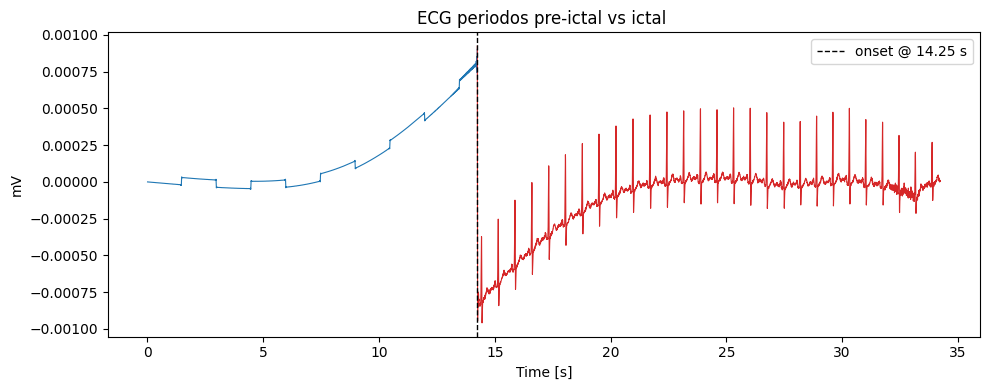

In [19]:
plt.figure(figsize=(10, 4))
df = pd.read_csv(
    '/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaajy_s001_t000.csv').iloc[1:].reset_index(drop=True)
t = df["Time [s]"].values
sig = df["Signal [mV]"].astype(float).values
lbl = df["Seizure [bool]"].astype(bool).values

x = 5000
x0 = 2000
# plt.plot(t[onset_idx:i1], sig[onset_idx:i1],
#             color="tab:red",  lw=0.8, label="seizure")

# plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
#             label=f"onset @ {t[onset_idx]:.2f} s")

# sig = denoise_ecg(sig)

onset_idx = np.flatnonzero(lbl)[0]
plt.plot(t[x0:x], sig[x0:x],
         color="tab:blue", lw=0.8, label="pre-seizure")
plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
            label=f"onset @ {t[onset_idx]:.2f} s")
plt.xlabel("Time [s]")
plt.ylabel("mV")
plt.title("ECG around first seizure")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
df = pd.read_csv(
    '/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s001_t001.csv').iloc[1:].reset_index(drop=True)
t = df["Time [s]"].values
sig = df["Signal [mV]"].astype(float).values
lbl = df["Seizure [bool]"].astype(bool).values


# plt.plot(t[onset_idx:i1], sig[onset_idx:i1],
#             color="tab:red",  lw=0.8, label="seizure")

# plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
#             label=f"onset @ {t[onset_idx]:.2f} s")
sig = denoise_ecg(sig)

# onset_idx = np.flatnonzero(lbl)[0]
plt.plot(t[x0:x], sig[x0:x],
         color="tab:blue", lw=0.8, label="pre-seizure")
plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
            label=f"onset @ {t[onset_idx]:.2f} s")
plt.xlabel("Time [s]")
plt.ylabel("mV")
plt.title("ECG around first seizure")
plt.legend()
plt.tight_layout()
plt.show()


plot_onset_window(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaajy_s001_t000.csv", denoise=False)
plot_onset_window(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaajy_s003_t005.csv", denoise=False)
plot_onset_window(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaajy_s001_t000.csv", denoise=False)

In [ ]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path
notebook_path = Path().resolve()               # default is os.getcwd()

all_csv_paths = notebook_path.parent / "data/raw"

# get all csv file name
all_csv_paths = list(all_csv_paths.glob("*.csv"))
all_csv_paths = [str(path) for path in all_csv_paths]
all_csv_paths

# only name of csv
all_csv_names = [os.path.basename(path) for path in all_csv_paths]

raw_data_folder = notebook_path.parent / 'data_ecg/raw_ecg'

for csv in all_csv_paths:

    df = pd.read_csv(csv)
    name = os.path.basename(csv)
    df = df.iloc[1:]
    df.to_csv(raw_data_folder / name, index=False)

In [ ]:
from pathlib import Path
import os
# 1) Resolve current directory and get “data” sibling
notebook_path = Path().resolve()               # default is os.getcwd()
# parent of notebooks is myproject
data_folder = notebook_path.parent / 'data/raw'
data_folder_seizure_ecg = notebook_path.parent / 'data_ecg/seizure_ecg'
data_folder_no_seizure = notebook_path.parent / 'data_ecg/no_seizure_ecg'

raw_data_folder = notebook_path.parent / 'data_ecg/raw_ecg'
csv_files = list(data_folder.glob('*.csv'))

[PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaabjo_s002_t001.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaahie_s011_t006.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaapnl_s005_t005.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaasgd_s005_t001.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaanzg_s001_t000.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaascj_s004_t006.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaamoa_s003_t000.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaapli_s002_t009.csv'),
 PosixPath('/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaarso_

In [ ]:
from pathlib import Path
import os
# 1) Resolve current directory and get “data” sibling
notebook_path = Path().resolve()               # default is os.getcwd()
# parent of notebooks is myproject
data_folder = notebook_path.parent / 'data/raw'
data_folder_seizure_ecg = notebook_path.parent / 'data_ecg/seizure_ecg'
data_folder_no_seizure = notebook_path.parent / 'data_ecg/no_seizure_ecg'

raw_data_folder = notebook_path.parent / 'data_ecg/raw_ecg'
csv_files = list(data_folder.glob('*.csv'))
for csv_name in csv_files:
    df = pd.read_csv(csv_name)
    df.iloc[1:]
    df.to_csv(raw_data_folder / csv_name, index=False)

KeyboardInterrupt: 

In [ ]:

# 2) Grab all .csv files as Path objects
csv_files = list(data_folder.glob('*.csv'))

for csv in csv_files:
    print(csv)

/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaabjo_s002_t001.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaahie_s011_t006.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaapnl_s005_t005.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaasgd_s005_t001.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaanzg_s001_t000.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaascj_s004_t006.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaamoa_s003_t000.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaapli_s002_t009.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaarso_s005_t001.csv
/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaasgd_s004_t001.csv
/Users/ignaciagothe/

In [ ]:
dir_path = Path(os.getcwd())
plot_onset_window(
    "ecg_seizure/data/raw/aaaaaaac_s001_t000.csv", denoise=False)

FileNotFoundError: [Errno 2] No such file or directory: 'ecg_seizure/data/raw/aaaaaaac_s001_t000.csv'

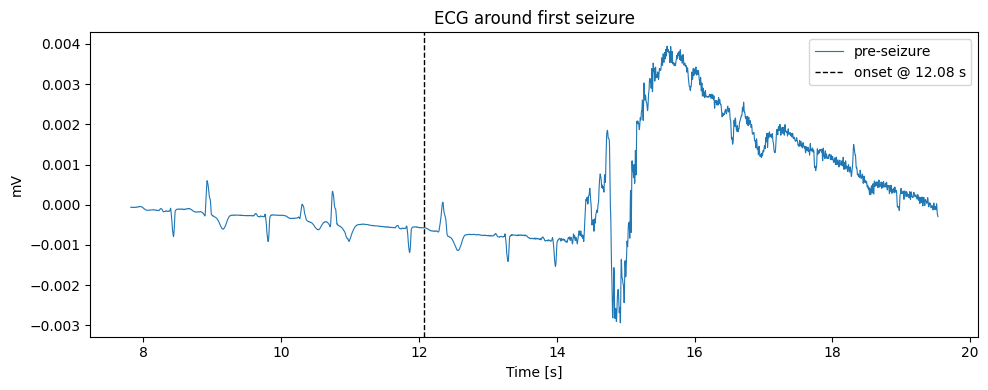

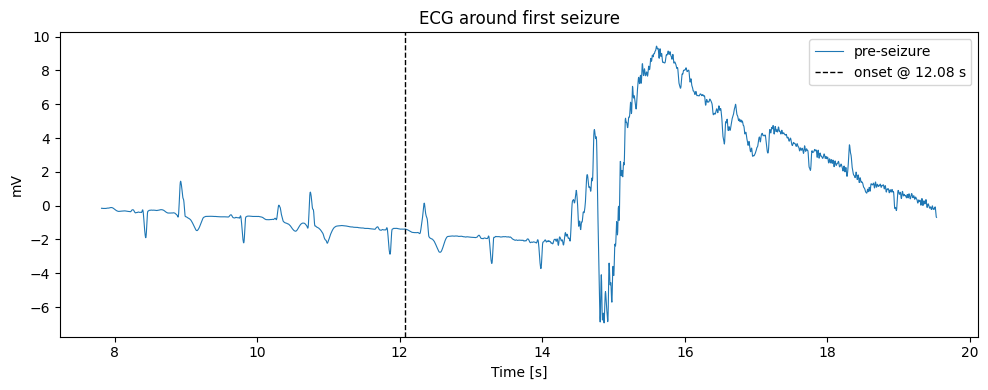

In [10]:
plt.figure(figsize=(10, 4))
df = pd.read_csv(
    '/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s001_t001.csv').iloc[1:].reset_index(drop=True)
t = df["Time [s]"].values
sig = df["Signal [mV]"].astype(float).values
lbl = df["Seizure [bool]"].astype(bool).values

x = 5000
x0 = 2000
# plt.plot(t[onset_idx:i1], sig[onset_idx:i1],
#             color="tab:red",  lw=0.8, label="seizure")

# plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
#             label=f"onset @ {t[onset_idx]:.2f} s")

# sig = denoise_ecg(sig)

onset_idx = np.flatnonzero(lbl)[0]
plt.plot(t[x0:x], sig[x0:x],
         color="tab:blue", lw=0.8, label="pre-seizure")
plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
            label=f"onset @ {t[onset_idx]:.2f} s")
plt.xlabel("Time [s]")
plt.ylabel("mV")
plt.title("ECG around first seizure")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
df = pd.read_csv(
    '/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s001_t001.csv').iloc[1:].reset_index(drop=True)
t = df["Time [s]"].values
sig = df["Signal [mV]"].astype(float).values
lbl = df["Seizure [bool]"].astype(bool).values


# plt.plot(t[onset_idx:i1], sig[onset_idx:i1],
#             color="tab:red",  lw=0.8, label="seizure")

# plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
#             label=f"onset @ {t[onset_idx]:.2f} s")
sig = denoise_ecg(sig)

# onset_idx = np.flatnonzero(lbl)[0]
plt.plot(t[x0:x], sig[x0:x],
         color="tab:blue", lw=0.8, label="pre-seizure")
plt.axvline(t[onset_idx], color="k", ls="--", lw=1,
            label=f"onset @ {t[onset_idx]:.2f} s")
plt.xlabel("Time [s]")
plt.ylabel("mV")
plt.title("ECG around first seizure")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
onset_idx = np.flatnonzero(lbl)[0]

In [24]:
onset_idx

np.int64(3091)

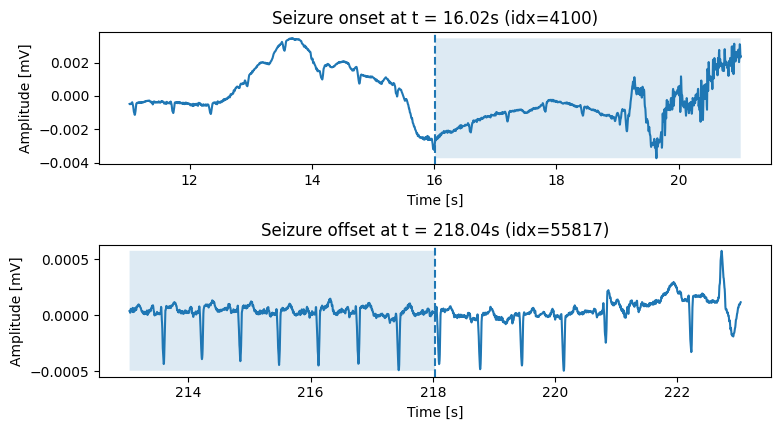

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def find_label_edges(lbl_bool: np.ndarray) -> tuple[list[int], list[int]]:
    """
    Return the sample indices where the label flips
      0 → 1  (seizure onset)
      1 → 0  (seizure offset)
    """
    padded = np.concatenate([[False], lbl_bool, [False]])
    edges = np.flatnonzero(np.diff(padded))          # every change
    onset_i = edges[0::2]                              # even positions → 0→1
    offset_i = edges[1::2]                             # odd  positions → 1→0
    return onset_i.tolist(), offset_i.tolist()


def plot_context(ax, t, sig, lbl, idx, pre_s=5, post_s=5):
    """
    Plot signal ± (pre_s, post_s) seconds around `idx`.
    """
    fs = 1.0 / np.mean(np.diff(t))               # sampling‐rate ≈ Hz
    win = int((pre_s + post_s) * fs)
    start = max(idx - int(pre_s*fs), 0)
    stop = min(idx + int(post_s*fs), len(sig)-1)
    sel = slice(start, stop)

    ax.plot(t[sel], sig[sel])
    ax.fill_between(t[sel], sig[sel].min(), sig[sel].max(),
                    where=lbl[sel], alpha=0.15)        # shaded seizure
    ax.axvline(t[idx], ls='--')                        # transition marker
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Amplitude [mV]')


def plot_all_transitions(raw_df, pre_s=5, post_s=5, max_plots=4):
    """
    Convenience wrapper — shows the first few onsets *and* offsets.
    """
    t = raw_df["Time [s]"].values
    sig = raw_df["Signal [mV]"].values
    lbl = raw_df["Seizure [bool]"].values.astype(bool)

    onsets, offsets = find_label_edges(lbl)

    n = min(len(onsets)+len(offsets), max_plots)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.2*n), sharex=False)

    pairs = [('onset', i) for i in onsets] + \
            [('offset', i) for i in offsets]
    # show earliest first, truncate if > max_plots
    for ax, (kind, idx) in zip(axes, sorted(pairs, key=lambda p: p[1])[:n]):
        plot_context(ax, t, sig, lbl, idx, pre_s, post_s)
        ax.set_title(f'Seizure {kind} at t = {t[idx]:.2f}s (idx={idx})')

    plt.tight_layout()
    plt.show()


raw_df = pd.read_csv(
    "/Users/ignaciagothe/Ignacia macbook/Proyecto Ecg ipre/ecg_seizure/data/raw/aaaaaaac_s002_t000.csv").iloc[1:].reset_index(drop=True)
plot_all_transitions(raw_df, pre_s=5, post_s=5, max_plots=6)

In [12]:
df

,Time [s],Signal [mV],Seizure [bool]
0,0.003906,-2.647967e-06,0
1,0.007812,-6.201014e-06,0
2,0.011719,-5.640006e-06,0
3,0.015625,-4.925185e-07,0
4,0.019531,7.869718e-07,0
...,...,...,...
78330,305.980469,-1.878001e-04,0
78331,305.984375,-1.527322e-04,0
78332,305.988281,-1.183040e-04,0
78333,305.992188,-6.906336e-05,0


→ Claves encontradas en windows.npz: ['x', 'y']
→ X: (116825, 1282)   y: (116825,)


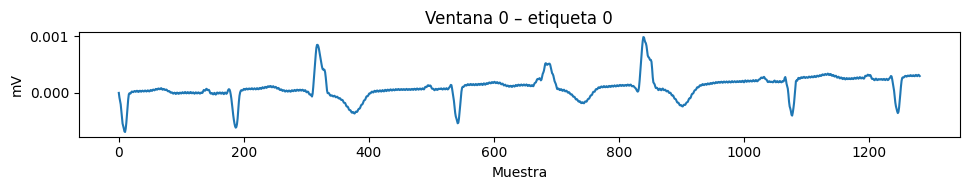

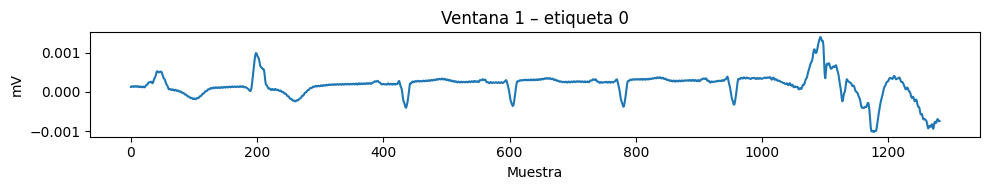

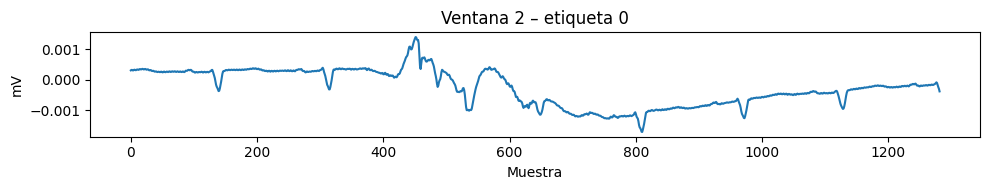

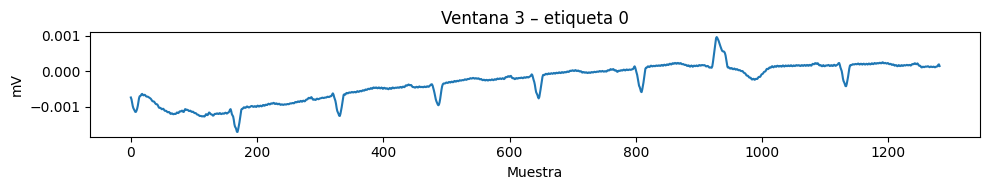

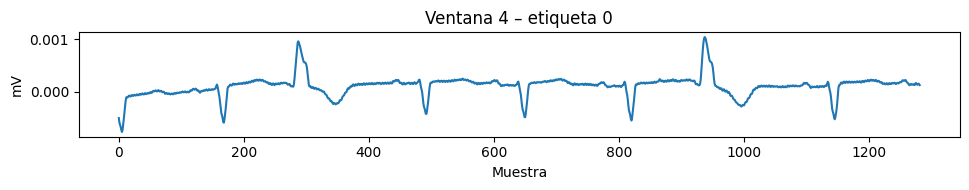

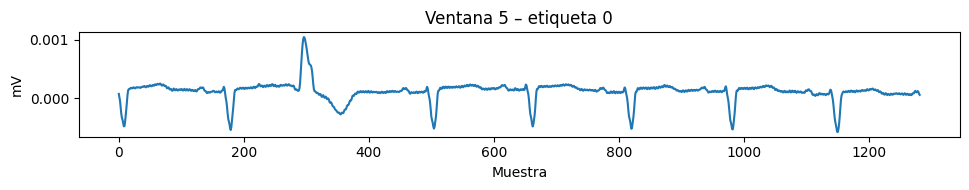

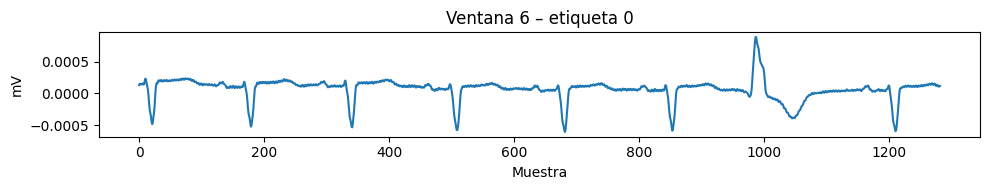

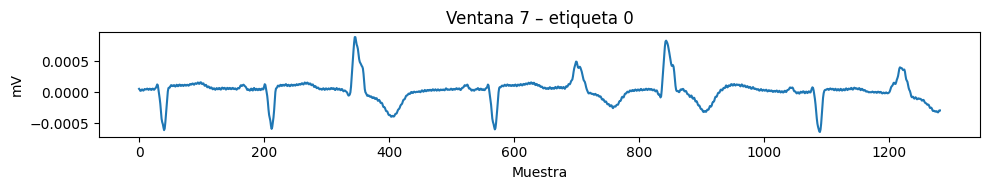

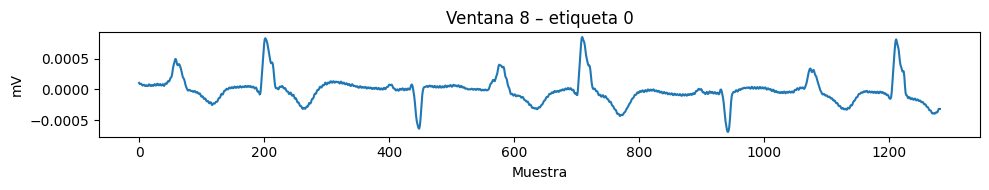

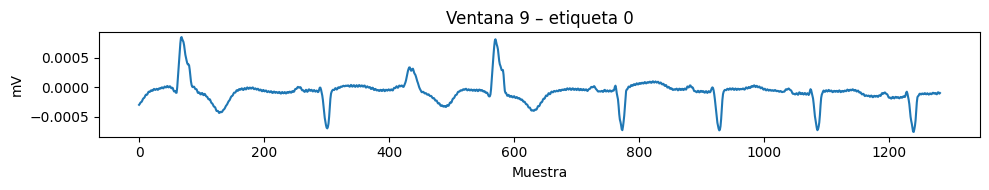

In [ ]:
# ───────────────────────────────────────────────────────────
#  ECG · Windows · Modelo  ─  Carga • Visualización • Métricas
# ───────────────────────────────────────────────────────────
#
#   1. Carga ventanas       (windows_mini.npz)
#   2. Sanity-check visual  (primeras N ventanas)
#   3. Restaura pesos       (best_model.pt, arquitectura InceptionTimeSE)
#   4. Inferencia           (probabilidades y clases)
#   5. Métricas             (ACC, Prec, Rec, F1, AUROC)
#   6. Matriz de confusión  (heat-map)
#
#   Autor: Ignacia - Mayo 2025
# ───────────────────────────────────────────────────────────

# ░░ Imports ────────────────────────────────────────────────
import os
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score
)
from src.models.inception import InceptionTimeSE
# npz = np.load("tests/windows.npz")
# print("Keys in NPZ:", npz.files)


# ░░ Configuración  ─────────────────────────────────────────
NPZ_PATH = Path("tests/windows.npz")
WEIGHTS_PATH = Path("tests/best_model_2.pt")
# punto de corte para logits→clase
N_PLOTS = 10                                # nº de ventanas a graficar

device = torch.device("mps")

# ░░ 1. Cargar las ventanas ─────────────────────────────────
npz = np.load(NPZ_PATH)
print(f"→ Claves encontradas en {NPZ_PATH.name}: {npz.files}")

X = npz["x"]          # (N,T)  o  (N,C,T)
y = npz["y"]


print(f"→ X: {X.shape}   y: {y.shape}")

# ░░ 2. Visualizar N ventanas para sanity-check ─────────────


def plot_window(idx: int) -> None:
    sig = X[idx].squeeze()
    plt.figure(figsize=(10, 2))
    plt.plot(sig)
    plt.title(f"Ventana {idx} – etiqueta {int(y[idx])}")
    plt.xlabel("Muestra")
    plt.ylabel("mV")
    plt.tight_layout()
    plt.show()


for i in range(min(N_PLOTS, len(X))):
    plot_window(i)

In [8]:
npz["x"][0]

array([-2.2024796e-08, -8.3238592e-05, -1.3761991e-04, ...,
        3.1946818e-04,  3.1212231e-04,  2.9819808e-04],
      shape=(1282,), dtype=float32)

In [ ]:

# ░░ 3. Crear y restaurar el modelo ─────────────────────────
model = InceptionTimeSE(
    n_blocks=6,
    in_channels=X.shape[1],
    n_classes=1,
    out_channels=32,
    bottleneck_channels=32,
    kernel_sizes=[10, 20, 40],
    use_se=True,
).to(device)

state_dict = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(state_dict, strict=True)
model.eval()

# ░░ 4. DataLoader + inferencia ─────────────────────────────
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

loader = DataLoader(
    TensorDataset(X_t, y_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(device.type == "cuda"),
)

y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)             # (B,)
        prob = torch.sigmoid(logits).cpu().numpy()

        y_prob.extend(prob)
        y_pred.extend((prob >= THRESHOLD).astype(int))
        y_true.extend(yb.numpy().astype(int))

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)

# ░░ 5. Métricas ────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
auc = roc_auc_score(y_true, y_prob)

print("\n───────── Métricas globales ─────────")
print(f"Accuracy : {acc:0.4f}")
print(f"Precision: {prec:0.4f}")
print(f"Recall   : {rec:0.4f}")
print(f"F1-score : {f1:0.4f}")
print(f"AUROC    : {auc:0.4f}")

# ░░ 6. Matriz de confusión (heat-map) ─────────────────────
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Matriz de Confusión")
ax.set_xlabel("Predicho")
ax.set_ylabel("Verdadero")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.show()

# ░░ Fin ────────────────────────────────────────────────────

In [ ]:
# load pt model